In [ ]:
!pip install fuzzywuzzy[speedup] nltk


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 30.5 MB/s eta 0:00:00


In [ ]:
from google.colab import files

uploaded = files.upload()  # Upload your WhatsApp .txt file


Saving whatsapp_chat.txt to whatsapp_chat.txt


In [ ]:
import io

chat_data = io.StringIO(next(iter(uploaded.values())).decode("utf-8"))
lines = chat_data.readlines()
for line in lines[:10]:
    print(line)  # View first 10 lines


29/06/2025, 05:51 AM - Neha: I think he wants to attack someone.

10/06/2025, 05:04 PM - Raj: Sometimes I just feel so suicide...

13/06/2025, 04:36 PM - Neha: They were talking about dope again...

14/06/2025, 06:56 PM - Raj: Why do I feel suicide all the time?

23/06/2025, 10:44 AM - Amit: You bastard, this is unbelievable!

30/06/2025, 12:19 AM - Amit: They were talking about heroin again...

06/07/2025, 07:57 AM - Amit: Did you share your fraud details?

23/06/2025, 03:36 PM - Raj: Sometimes I just feel so no one cares...

24/06/2025, 10:55 AM - Sneha: Why do I feel lonely all the time?

17/06/2025, 09:44 AM - Sneha: That party had so much marijuana going on.



In [ ]:
import re
import pandas as pd

# # Load lines from uploaded file
# with open('/mnt/data/chat sample.txt', 'r', encoding='utf-8') as f:
#     lines = f.readlines()

# Updated regex pattern for your file's format: "26 Sep 2014 12:53 - Sender: Message"
pattern = r"(\d{2}/\d{2}/\d{4}), (\d{1,2}:\d{2} (?:AM|PM)) - ([^:]+): (.+)"


data = []
for line in lines:
    match = re.match(pattern, line)
    if match:
        date, time, sender, message = match.groups()
        data.append([f"{date} {time}", sender, message])

# Create DataFrame
df = pd.DataFrame(data, columns=["timestamp", "sender", "message"])

# Convert timestamp to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"], format="%d/%m/%Y %I:%M %p")

# Preview output
print(df.head(50))

             timestamp sender                                         message
0  2025-06-29 05:51:00   Neha             I think he wants to attack someone.
1  2025-06-10 17:04:00    Raj             Sometimes I just feel so suicide...
2  2025-06-13 16:36:00   Neha           They were talking about dope again...
3  2025-06-14 18:56:00    Raj             Why do I feel suicide all the time?
4  2025-06-23 10:44:00   Amit              You bastard, this is unbelievable!
5  2025-06-30 00:19:00   Amit         They were talking about heroin again...
6  2025-07-06 07:57:00   Amit               Did you share your fraud details?
7  2025-06-23 15:36:00    Raj        Sometimes I just feel so no one cares...
8  2025-06-24 10:55:00  Sneha              Why do I feel lonely all the time?
9  2025-06-17 09:44:00  Sneha      That party had so much marijuana going on.
10 2025-06-16 13:08:00  Sneha            I think he wants to revenge someone.
11 2025-06-14 21:24:00   Neha                   You fk, this is 

The day with the highest message count is: 2025-06-14
Number of messages on that day: 6
The day with the lowest message count is: 2025-06-13
Number of messages on that day: 1


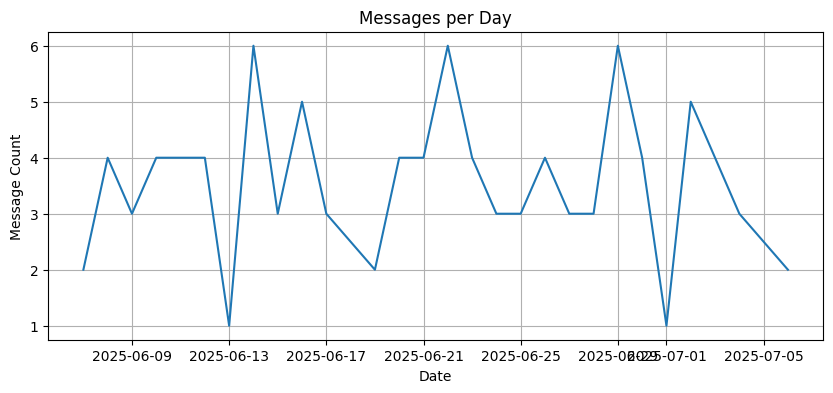

In [ ]:
import matplotlib.pyplot as plt

df["date"] = df["timestamp"].dt.date
daily_counts = df["date"].value_counts().sort_index()

highest_msg_day = daily_counts.idxmax()
highest_msg_count = daily_counts.max()
lowest_msg_day = daily_counts.idxmin()
lowest_msg_count = daily_counts.min()

print(f"The day with the highest message count is: {highest_msg_day}")
print(f"Number of messages on that day: {highest_msg_count}")
print(f"The day with the lowest message count is: {lowest_msg_day}")
print(f"Number of messages on that day: {lowest_msg_count}")

plt.figure(figsize=(10,4))
daily_counts.plot()
plt.title("Messages per Day")
plt.xlabel("Date")
plt.ylabel("Message Count")
plt.grid(True)
plt.show()


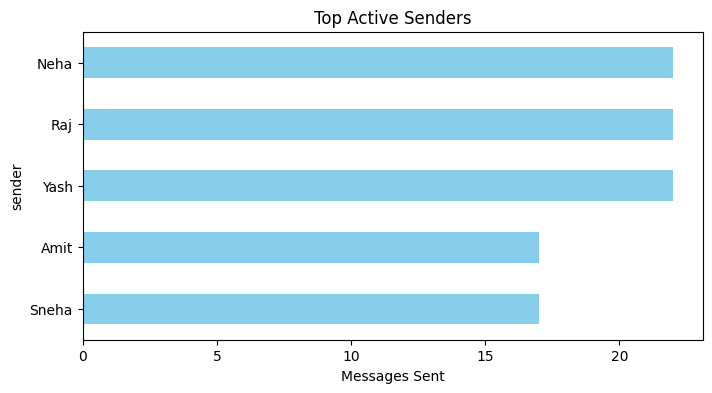

In [ ]:
top_senders = df["sender"].value_counts().head(10)

plt.figure(figsize=(8,4))
top_senders.plot(kind="barh", color="skyblue")
plt.title("Top Active Senders")
plt.xlabel("Messages Sent")
plt.gca().invert_yaxis()
plt.show()


In [ ]:
from fuzzywuzzy import fuzz
from nltk.tokenize import word_tokenize
import seaborn as sns
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Download the 'punkt' tokenizer
nltk.download('punkt')
nltk.download('punkt_tab') # Download the missing resource

offensive_categories = {
    "abuse": [
        "idiot", "stupid", "bastard", "fool", "dumb", "loser", "moron", "shit", "asshole", "bloody",
        "bullshit", "f**k", "fu*k", "fuk", "fk", "fck", "motherf", "mf", "b!tch", "b1tch", "bich"
    ],
    "threats": [
        "kill", "murder", "die", "burn", "hang", "bomb", "revenge", "stab", "attack", "destroy"
    ],
    "depression": [
        "suicide", "die", "worthless", "hopeless", "lonely", "cut", "selfharm", "depressed", "no one cares"
    ],
    "sexual": [
        "rape", "molest", "sex", "nude", "naked", "harass", "abuse", "suck", "d1ck", "d*ck", "penis", "boobs",
        "b00bs", "pussy", "cum", "orgasm", "ejaculate", "lick", "69"
    ],
    "financial": [
        "account", "password", "otp", "upi", "bank", "loan", "credit", "debit", "card", "pin", "fraud"
    ],
    "drugs": [
        "weed", "cocaine", "heroin", "marijuana", "hash", "acid", "lsd", "pill", "dope", "meth", "snort"
    ]
}

def flag_offensive_words(message, threshold=95):
    found = []
    words = [w for w in word_tokenize(message.lower()) if w.isalpha() and len(w) > 2]

    for category, keywords in offensive_categories.items():
        for word in words:
            for keyword in keywords:
                if fuzz.partial_ratio(word, keyword) >= threshold:
                    found.append((word, category))
    return found

df["flags_detailed"] = df["message"].apply(flag_offensive_words)
flagged = df[df["flags_detailed"].apply(lambda x: len(x) > 0)].copy()

# Extract just the matched words and categories
flagged["flagged_words"] = flagged["flags_detailed"].apply(lambda lst: [w[0] for w in lst])
flagged["flagged_categories"] = flagged["flags_detailed"].apply(lambda lst: list(set(c for _, c in lst)))
flagged.head(10)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,timestamp,sender,message,date,flags_detailed,flagged_words,flagged_categories
0,2025-06-29 05:51:00,Neha,I think he wants to attack someone.,2025-06-29,"[(attack, threats)]",[attack],[threats]
1,2025-06-10 17:04:00,Raj,Sometimes I just feel so suicide...,2025-06-10,"[(suicide, depression)]",[suicide],[depression]
2,2025-06-13 16:36:00,Neha,They were talking about dope again...,2025-06-13,"[(dope, drugs)]",[dope],[drugs]
3,2025-06-14 18:56:00,Raj,Why do I feel suicide all the time?,2025-06-14,"[(the, abuse), (suicide, depression)]","[the, suicide]","[abuse, depression]"
4,2025-06-23 10:44:00,Amit,"You bastard, this is unbelievable!",2025-06-23,"[(bastard, abuse)]",[bastard],[abuse]
5,2025-06-30 00:19:00,Amit,They were talking about heroin again...,2025-06-30,"[(heroin, drugs)]",[heroin],[drugs]
6,2025-07-06 07:57:00,Amit,Did you share your fraud details?,2025-07-06,"[(fraud, financial)]",[fraud],[financial]
7,2025-06-23 15:36:00,Raj,Sometimes I just feel so no one cares...,2025-06-23,"[(one, depression), (one, depression), (cares,...","[one, one, cares]",[depression]
8,2025-06-24 10:55:00,Sneha,Why do I feel lonely all the time?,2025-06-24,"[(the, abuse), (lonely, depression)]","[the, lonely]","[abuse, depression]"
9,2025-06-17 09:44:00,Sneha,That party had so much marijuana going on.,2025-06-17,"[(marijuana, drugs)]",[marijuana],[drugs]


/tmp/ipython-input-11-3907735101.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[w[0] for w in top_words], y=[w[1] for w in top_words], palette="Reds")


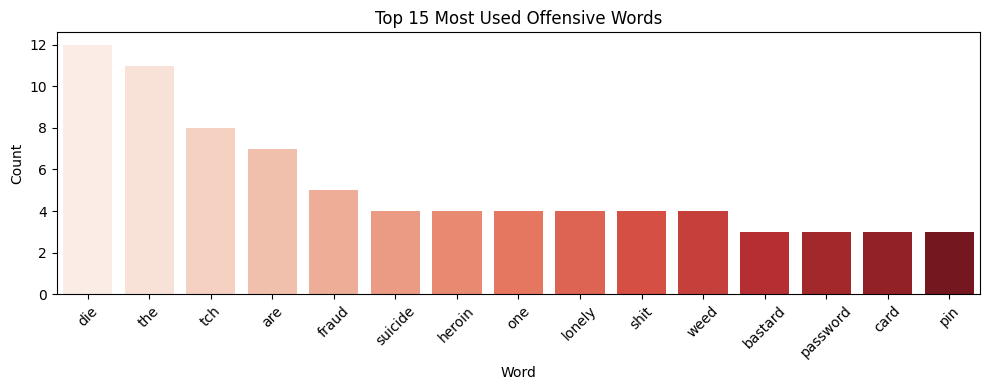

In [ ]:
from collections import Counter

all_words = sum(flagged["flagged_words"], [])
word_count = Counter(all_words)

top_words = word_count.most_common(15)

plt.figure(figsize=(10,4))
sns.barplot(x=[w[0] for w in top_words], y=[w[1] for w in top_words], palette="Reds")
plt.title("Top 15 Most Used Offensive Words")
plt.xlabel("Word")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipython-input-12-3096423344.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[u[0] for u in sorted_users[:10]], y=[u[1] for u in sorted_users[:10]], palette="coolwarm")


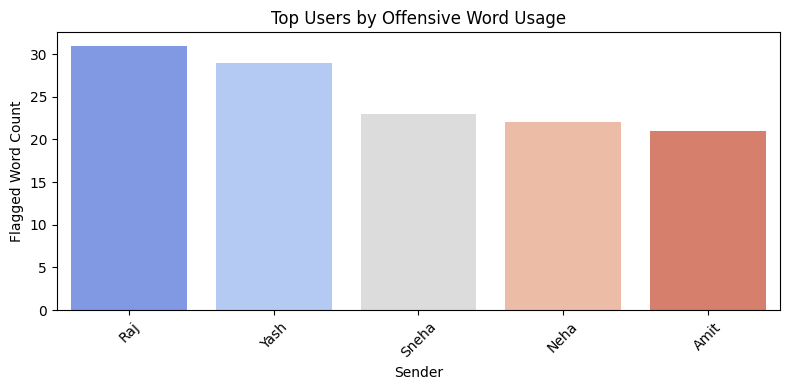

In [ ]:
from collections import defaultdict

user_word_count = defaultdict(int)

for _, row in flagged.iterrows():
    user_word_count[row["sender"]] += len(row["flagged_words"])

sorted_users = sorted(user_word_count.items(), key=lambda x: x[1], reverse=True)

plt.figure(figsize=(8,4))
sns.barplot(x=[u[0] for u in sorted_users[:10]], y=[u[1] for u in sorted_users[:10]], palette="coolwarm")
plt.title("Top Users by Offensive Word Usage")
plt.ylabel("Flagged Word Count")
plt.xlabel("Sender")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
